# 2.1 DWD Station -> NUTS-3 Mapping

This continues the deeper exploration of data sources.

**Goals:**

1. assess **station density per NUTS-3 district for Germany**
2. load the full DWD CDC station inventory (~1,400 KL climate stations) into the analytical store (via spatial-join to NUTS-3 polygons in DuckDB)

**Key questions:**

1. How many stations fall in each NUTS-3 district?
2. Which districts have zero coverage? (=> nearest-station fallback needed)
3. Is the station network dense enough for a simple station-average approach at NUTS-3?

**Data source**: [DWD CDC station list](https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/kl/historical/) — free, no auth required.

**Decision criteria**: If ≥80% of German NUTS-3 districts have at least 1 station => reliable, hence **ingest** and work with it. Otherwise evaluate gridded products.

## Prerequisites

In [1]:
import io
from pathlib import Path

import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import requests

In [2]:
CACHE_DIR = Path("_cache")
DB_PATH = CACHE_DIR / "agri_weather_yield.duckdb"

con = duckdb.connect(str(DB_PATH))
con.load_extension("spatial")

Check if NUTS tables exist

In [3]:
tables = [t[0] for t in con.sql("SHOW TABLES").fetchall()]
tables

['data_source_registry',
 'dwd_stations',
 'dwd_stations_nuts3',
 'nuts0',
 'nuts1',
 'nuts2',
 'nuts3',
 'nuts_hierarchy']

In [4]:
assert "nuts3" in tables, "Run nuts3-duckdb-data-lake.ipynb first!"

Count German NUTS3 districts:

In [5]:
con.sql("select count(*) from nuts3 where cntr_code='DE'").fetchone()[0]

401

## 1. Fetch DWD KL station inventory

The DWD station list is a fixed-width text file at the top of the KL historical directory. It contains station ID, coordinates (lat/lon), elevation, name, and operational period for every station with historical daily climate data.

In [6]:
DWD_BASE_URL = "https://opendata.dwd.de/climate_environment/CDC/"

In [7]:
DWD_STATION_LIST_URL = DWD_BASE_URL + "observations_germany/climate/daily/kl/historical/KL_Tageswerte_Beschreibung_Stationen.txt"

cache_path = CACHE_DIR / "dwd_kl_stations.txt"
if cache_path.exists():  # TODO: evict cache if too old; stations don't change frequently though.
    print(f"Loading from cache: {cache_path}")
    raw = cache_path.read_text(encoding="utf-8")
else:
    print(f"Downloading: {DWD_STATION_LIST_URL}")
    resp = requests.get(DWD_STATION_LIST_URL, timeout=30)
    resp.raise_for_status()
    raw = resp.content.decode("latin-1")
    cache_path.write_text(raw, encoding="utf-8")
    print(f"Cached to: {cache_path}")

# Preview the header
for line in raw.splitlines()[:5]:
    print(line)

Loading from cache: _cache/dwd_kl_stations.txt
Stations_id von_datum bis_datum Stationshoehe geoBreite geoLaenge Stationsname Bundesland Abgabe
----------- --------- --------- ------------- --------- --------- ----------------------------------------- ---------- ------
00001 19370101 19860630            478     47.8413    8.8493 Aach                                     Baden-Württemberg                        Frei                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       

As seen previously, it's a fixed-width format with 2 header lines.

In [8]:
dwd_header = raw[:256].split("\n")[0].strip().split()
dwd_header

['Stations_id',
 'von_datum',
 'bis_datum',
 'Stationshoehe',
 'geoBreite',
 'geoLaenge',
 'Stationsname',
 'Bundesland',
 'Abgabe']

In [9]:
# Rename for convenience
dwd_cols = ["station_id", "date_from", "date_to", "elevation_m", "lat", "lon", "name_raw", "bundesland", "extra"]

In [10]:
stations_df = pd.read_fwf(
    io.StringIO(raw),
    names=dwd_cols,
    skiprows=2,
    # index_col=0,
    parse_dates=["date_from", "date_to"],
    dtype={"extra": "category", "station_id": str},
)

# Add number of years in service
stations_df["years_active"] = ((stations_df["date_to"] - stations_df["date_from"]).dt.days / 365.25).round(1)
stations_df

,station_id,date_from,date_to,elevation_m,lat,lon,name_raw,bundesland,extra,years_active
0,00001,1937-01-01,1986-06-30,478,47.8413,8.8493,Aach,Baden-Württemberg,Frei,49.5
1,00003,1891-01-01,2011-03-31,202,50.7827,6.0941,Aachen,Nordrhein-Westfalen,Frei,120.2
2,00011,1980-09-01,2026-03-07,680,47.9736,8.5205,Donaueschingen (Landeplatz),Baden-Württemberg,Frei,45.5
3,00044,1969-01-01,2026-03-07,44,52.9336,8.2370,Großenkneten,Niedersachsen,Frei,57.2
4,00052,1969-01-01,2001-12-31,46,53.6623,10.1990,Ahrensburg-Wulfsdorf,Schleswig-Holstein,Frei,33.0
...,...,...,...,...,...,...,...,...,...,...
1377,19985,1981-01-01,2003-12-31,455,48.8457,8.9073,Weissach/Strudelbach,Baden-Württemberg,Frei,23.0
1378,19989,1936-01-01,2012-06-30,147,50.0681,8.2603,Wiesbaden (Südost),Hessen,Frei,76.5
1379,20007,1882-01-01,1915-12-31,332,50.8422,12.8770,Chemnitz-Altendorf,Sachsen,Frei,34.0
1380,20098,2025-04-01,2026-03-07,19,48.5651,8.2284,Seebach (Nationalpark Schwarzw,Baden-Württemberg,Frei,0.9


Date range

In [11]:
f"{stations_df['date_from'].min().date()} - {stations_df['date_to'].max().date()}"

'1759-11-01 - 2026-03-07'

Still active (`bis_datum >= 2024`)

In [12]:
count = (stations_df["date_to"] >= "2024-01-01").sum()
total = len(stations_df)

f"Still active total: {count}, proportion: {round(100 * count / total, 2)}%"

'Still active total: 576, proportion: 41.68%'

## 2. Ingest stations into DuckDB & spatial-join to NUTS-3

Goal: Assign each station to its Landkreis.

Approach: Register station locations as points, then `ST_Contains` join against NUTS-3 polygons.

### Ingest stations

Create table with geometry:

In [13]:
con.sql("drop table if exists dwd_stations")

con.sql("""
    create table dwd_stations as
    select
        station_id,
        name_raw AS station_name,
        date_from,
        date_to,
        elevation_m,
        lat,
        lon,
        years_active,
        ST_Point(lon, lat) AS geometry
    from stations_df
""")

with a total of 1382 rows:

In [14]:
n = con.sql("select count(*) from dwd_stations").fetchone()[0]
n

1382

### Spatial join: station -> NUTS-3

In [15]:
con.sql("drop table if exists dwd_stations_nuts3")

con.sql("""
    create table dwd_stations_nuts3 as
    select
        s.station_id,
        s.station_name,
        s.lat,
        s.lon,
        s.elevation_m,
        s.date_from,
        s.date_to,
        s.years_active,
        n.nuts_id   as nuts3_id,
        n.nuts_name  as nuts3_name,
        n.nuts1_code,
        n.nuts2_code,
        n.cntr_code  as country_code
    from dwd_stations s
    join nuts3        n on st_contains(n.geometry, s.geometry)
""")

Quick verification of the association:

In [16]:
matched = con.sql("select count(*) from dwd_stations_nuts3").fetchone()[0]
unmatched = n - matched

print(f"""
Stations matched to NUTS-3: {matched}
Stations unmatched:         {unmatched} (likely on borders or offshore)
Match rate:                 {matched / n * 100:.1f}%
""")


Stations matched to NUTS-3: 1351
Stations unmatched:         31 (likely on borders or offshore)
Match rate:                 97.8%



In [17]:
unmatched_stations_df = con.sql("""
    select *
    from dwd_stations d
    -- where not exists (select 1 from dwd_stations_nuts3 n where n.station_id = d.station_id)
    anti join dwd_stations_nuts3 n on n.station_id = d.station_id
""").df()
unmatched_stations_df.head(3)

,station_id,station_name,date_from,date_to,elevation_m,lat,lon,years_active,geometry
0,00102,Leuchtturm Alte Weser,1998-01-01,2026-03-07,0,53.8633,8.1275,28.2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
1,00183,Arkona,1947-01-01,2026-03-07,42,54.6791,13.4344,79.2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
2,00335,Behrensdorf,1976-12-01,1977-10-31,4,54.3426,10.6018,0.9,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."


### Visualize stations that can't be assigned to NUTS-3 polygons

To check our assumption that all 31 stations are seashore or offshore stations and could therefore not be assigned to a NUTS-3 region, let's plot them on an outline of Germany.

In [18]:
unmatched_stations_gdf = gpd.GeoDataFrame(
    unmatched_stations_df.drop(columns=["geometry"]),
    geometry=gpd.points_from_xy(unmatched_stations_df["lon"], unmatched_stations_df["lat"]),
    crs="EPSG:4326",
)
unmatched_stations_gdf[["station_id", "station_name", "lat", "lon", "years_active"]].head(3)

,station_id,station_name,lat,lon,years_active
0,00102,Leuchtturm Alte Weser,53.8633,8.1275,28.2
1,00183,Arkona,54.6791,13.4344,79.2
2,00335,Behrensdorf,54.3426,10.6018,0.9


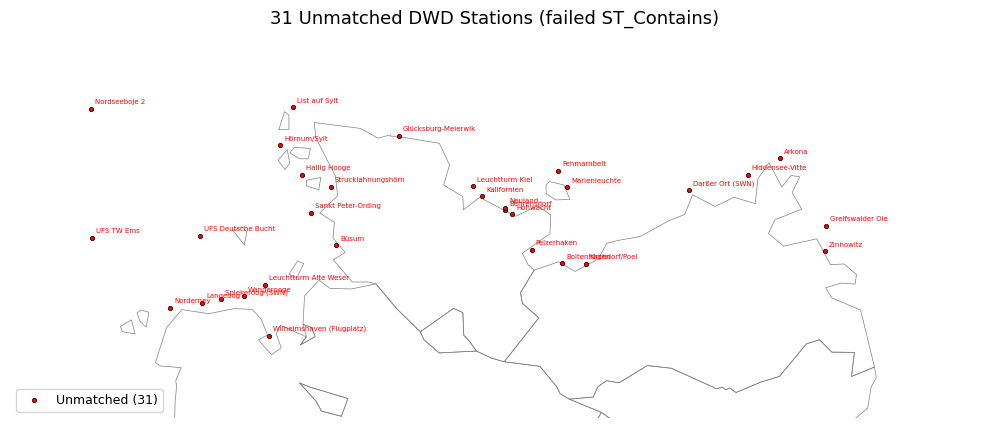

In [19]:
# Quick DE Bundesland boundary for context (NUTS-1 dissolved outline)
de_outline = gpd.GeoDataFrame(
    geometry=gpd.GeoSeries.from_wkb(
        con.sql("""
            select st_aswkb(geometry) as g from nuts1 where cntr_code = 'DE'
        """)
        .df()["g"]
        .apply(bytes)
    ),
    crs="EPSG:4326",
)

fig, ax = plt.subplots(figsize=(10, 12))
de_outline.boundary.plot(ax=ax, edgecolor="gray", linewidth=0.5)

# Unmatched stations (red)
ax.scatter(
    unmatched_stations_gdf.geometry.x,
    unmatched_stations_gdf.geometry.y,
    s=10,
    c="red",
    edgecolor="black",
    linewidth=0.5,
    zorder=5,
    label=f"Unmatched ({len(unmatched_stations_gdf)})",
)

for _, row in unmatched_stations_gdf.iterrows():
    ax.annotate(
        row["station_name"],
        (row["lon"], row["lat"]),
        fontsize=5,
        ha="left",
        va="bottom",
        xytext=(3, 3),
        textcoords="offset points",
        color="red",
        zorder=6,
    )

ax.set_xlim(5.5, 15.5)
ax.set_ylim(53.0, 55.5)  # top ~fifth (North Sea + Baltic coast)

ax.set_title(f"{len(unmatched_stations_gdf)} Unmatched DWD Stations (failed ST_Contains)", fontsize=13)
ax.legend(loc="lower left", fontsize=9)
ax.set_axis_off()
plt.tight_layout()
plt.show()

So really all of them are off the shore. Due to the maritime idisyncrasies in weather data, they are safe to discard for our purposes. On top of that, they are too remote from our sandy-soil region of interest - Lusatia.

## 3. Station density analysis

How many KL stations per NUTS-3 district? Focus on recent/active stations (still reporting in 2024+).

### Station density per NUTS-3 (all stations)

In [20]:
density_all_df = con.sql("""
    select
        n.nuts_id                                             as nuts3_id,
        n.nuts_name                                           as nuts3_name,
        n.nuts1_code,
        count(s.station_id)                                   as n_stations_all,
        count(case when s.date_to >= '2024-01-01' then 1 end) as n_stations_active,
        count(case when s.years_active >= 20 then 1 end)      as n_stations_long_record
    from      nuts3              n
    left join dwd_stations_nuts3 s on n.nuts_id = s.nuts3_id
    where n.cntr_code = 'DE'
    group by 1, 2, 3
    order by n_stations_active asc, n.nuts_id
""").df()
density_all_df.head(3)

,nuts3_id,nuts3_name,nuts1_code,n_stations_all,n_stations_active,n_stations_long_record
0,DE117,"Heilbronn, Stadtkreis",DE1,1,0,1
1,DE122,"Karlsruhe, Stadtkreis",DE1,1,0,1
2,DE125,"Heidelberg, Stadtkreis",DE1,2,0,2


Coverage summary (401 German NUTS-3 districts)

In [21]:
for col, label in [
    ("n_stations_all", "All historical stations"),
    ("n_stations_active", "Active (reporting 2024+)"),
    ("n_stations_long_record", "Long record (≥20 years)"),
]:
    has = (density_all_df[col] > 0).sum()
    zero = (density_all_df[col] == 0).sum()
    print(f"  {label:35s}: {has:3d} with ≥1 station | {zero:3d} with 0  ({has / 401 * 100:.0f}%)")

  All historical stations            : 365 with ≥1 station |  36 with 0  (91%)
  Active (reporting 2024+)           : 303 with ≥1 station |  98 with 0  (76%)
  Long record (≥20 years)            : 344 with ≥1 station |  57 with 0  (86%)


Distribution of active station count per NUTS-3

In [22]:
density_all_df["n_stations_active"].describe()

count    401.000000
mean       1.374065
std        1.220543
min        0.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        6.000000
Name: n_stations_active, dtype: float64

### Districts with zero active stations

In [23]:
zero_coverage = density_all_df[density_all_df["n_stations_active"] == 0].copy()

In [24]:
print("Total:", len(zero_coverage))

Total: 98


In [25]:
for _, row in zero_coverage.iterrows():
    fallback = "has historical < 2024" if row["n_stations_all"] > 0 else "NO stations at all"
    print(f"  {row['nuts3_id']} {row['nuts3_name']:35s} ({fallback})")

  DE117 Heilbronn, Stadtkreis               (has historical < 2024)
  DE122 Karlsruhe, Stadtkreis               (has historical < 2024)
  DE125 Heidelberg, Stadtkreis              (has historical < 2024)
  DE129 Pforzheim, Stadtkreis               (has historical < 2024)
  DE142 Tübingen, Landkreis                 (has historical < 2024)
  DE144 Ulm, Stadtkreis                     (has historical < 2024)
  DE211 Ingolstadt, Kreisfreie Stadt        (has historical < 2024)
  DE214 Altötting                           (NO stations at all)
  DE21E Landsberg am Lech                   (has historical < 2024)
  DE21L Starnberg                           (has historical < 2024)
  DE221 Landshut, Kreisfreie Stadt          (has historical < 2024)
  DE222 Passau, Kreisfreie Stadt            (has historical < 2024)
  DE223 Straubing, Kreisfreie Stadt         (NO stations at all)
  DE233 Weiden i. d. Opf, Kreisfreie Stadt  (NO stations at all)
  DE238 Regensburg, Landkreis               (NO stations 

### Lusatia focus: Brandenburg (DE4) + Saxony (DED)


1. Lower Lusatia (Brandenburg):
   - DE402 — Cottbus (kreisfreie Stadt)
   - DE40B — Dahme-Spreewald
   - DE40C — Elbe-Elster
   - DE40E — Oberspreewald-Lausitz
   - DE40H — Spree-Neiße
2. Upper Lusatia (Saxony):
   - DED2C — Bautzen
   - DED2D — Görlitz

That's 7 NUTS-3 districts. Some broader definitions also include DE40D (Oder-Spree) partially.

For our focus area, we are covering more - all Brandenburg and sometimes also Berlin (high density). We are interested in the spread of sandy soils. Lusatia is a histroically signficant region for the analysis of sandy soils.

Lusatia-area station density. Recall:

- `n_stations_all` is the total count of DWD weather stations in the NUTS-3 region,
- `n_stations_active` is the number of stations in the region that are still active, and
- `n_stations_long_record` is the number of stations there with recordings ranging back 20 years and more.

In [26]:
lusatia_df = density_all_df[density_all_df["nuts1_code"].isin(["DE3", "DE4", "DED"])].copy()
lusatia_df = lusatia_df.sort_values("nuts3_id")
lusatia_df

,nuts3_id,nuts3_name,nuts1_code,n_stations_all,n_stations_active,n_stations_long_record
382,DE300,Berlin,DE3,20,4,12
31,DE401,"Brandenburg an der Havel, Kreisfreie Stadt",DE4,1,0,1
155,DE402,"Cottbus, Kreisfreie Stadt",DE4,2,1,1
32,DE403,"Frankfurt (Oder), Kreisfreie Stadt",DE4,1,0,1
156,DE404,"Potsdam, Kreisfreie Stadt",DE4,2,1,2
157,DE405,Barnim,DE4,3,1,2
158,DE406,Dahme-Spreewald,DE4,2,1,1
283,DE407,Elbe-Elster,DE4,3,2,2
159,DE408,Havelland,DE4,2,1,1
350,DE409,Märkisch-Oderland,DE4,3,3,2


Thereof, in Brandenburg:

In [27]:
print(
    f"{lusatia_df[lusatia_df['nuts1_code'] == 'DE4']['n_stations_active'].sum()} active stations",
    f"across {(lusatia_df['nuts1_code'] == 'DE4').sum()} districts",
)

27 active stations across 18 districts


and in Saxony:

In [28]:
print(
    f"{lusatia_df[lusatia_df['nuts1_code'] == 'DED']['n_stations_active'].sum()} active stations",
    f"across {(lusatia_df['nuts1_code'] == 'DED').sum()} districts",
)

27 active stations across 13 districts


Coverage gaps are evident:

In [29]:
lusatia_df[lusatia_df["n_stations_active"] == 0]

,nuts3_id,nuts3_name,nuts1_code,n_stations_all,n_stations_active,n_stations_long_record
31,DE401,"Brandenburg an der Havel, Kreisfreie Stadt",DE4,1,0,1
32,DE403,"Frankfurt (Oder), Kreisfreie Stadt",DE4,1,0,1
33,DE40G,Spree-Neiße,DE4,0,0,0
88,DED52,Leipzig,DED,1,0,1


We'll apply k-nearest neighbors for gap filling here.

## 4. Map: Station density across Germany

Choropleth of active station count per NUTS-3, with station points overlaid.

### Map: station density choropleth + station points

Pull NUTS-3 boundaries from DuckDB.

In [30]:
con.sql("""
    select s.station_id, n.nuts_id
    from dwd_stations s
    join nuts3        n on st_within(st_point(s.lon, s.lat), n.geometry)
    where n.cntr_code = 'DE'
""").df()

,station_id,NUTS_ID
0,00001,DE138
1,00003,DEA2D
2,00011,DE136
3,00044,DE94D
4,00052,DEF0F
...,...,...
1337,19985,DE112
1338,19989,DE714
1339,20007,DED41
1340,20098,DE134


and merge density data:

In [31]:
de_nuts3_df = con.sql("""
    select n.nuts_id
         , n.nuts_name
         , n.nuts1_code
         , d.n_stations_active
         , st_aswkb(geometry) as geom_wkb
    from nuts3 n
    left join density_all_df d on n.nuts_id = d.nuts3_id
    where cntr_code = 'DE'
    order by nuts_id
""").df()
de_nuts3_df

,NUTS_ID,NUTS_NAME,nuts1_code,n_stations_active,geom_wkb
0,DE111,"Stuttgart, Stadtkreis",DE1,1,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 7, 0, 0, 0, 34, 84..."
1,DE112,Böblingen,DE1,1,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 9, 0, 0, 0, 128, 1..."
2,DE113,Esslingen,DE1,2,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 7, 0, 0, 0, 160, 1..."
3,DE114,Göppingen,DE1,1,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 7, 0, 0, 0, 96, 23..."
4,DE115,Ludwigsburg,DE1,1,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 7, 0, 0, 0, 34, 84..."
...,...,...,...,...,...
396,DEG0K,Saale-Orla-Kreis,DEG,4,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 11, 0, 0, 0, 224, ..."
397,DEG0L,Greiz,DEG,2,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 12, 0, 0, 0, 214, ..."
398,DEG0M,Altenburger Land,DEG,1,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 7, 0, 0, 0, 78, 11..."
399,DEG0N,"Eisenach, Kreisfreie Stadt",DEG,1,"[1, 3, 0, 0, 0, 1, 0, 0, 0, 5, 0, 0, 0, 128, 4..."


Prepare df for Matplotlib (WKB -> GeoDataFrame):

In [32]:
de_nuts3_gdf = gpd.GeoDataFrame(
    de_nuts3_df.drop(columns=["geom_wkb"]),
    geometry=gpd.GeoSeries.from_wkb(de_nuts3_df["geom_wkb"].apply(bytes)),
    crs="EPSG:4326",
)
de_nuts3_gdf

,NUTS_ID,NUTS_NAME,nuts1_code,n_stations_active,geometry
0,DE111,"Stuttgart, Stadtkreis",DE1,1,"POLYGON ((9.24417 48.84701, 9.31365 48.77448, ..."
1,DE112,Böblingen,DE1,1,"POLYGON ((9.06485 48.75558, 9.10472 48.70908, ..."
2,DE113,Esslingen,DE1,2,"POLYGON ((9.5031 48.75394, 9.58248 48.53915, 9..."
3,DE114,Göppingen,DE1,1,"POLYGON ((9.98777 48.72725, 9.94407 48.63176, ..."
4,DE115,Ludwigsburg,DE1,1,"POLYGON ((9.24417 48.84701, 9.16518 48.85226, ..."
...,...,...,...,...,...
396,DEG0K,Saale-Orla-Kreis,DEG,4,"POLYGON ((11.94414 50.59128, 11.89675 50.54318..."
397,DEG0L,Greiz,DEG,2,"POLYGON ((12.22417 50.94293, 12.25083 50.81832..."
398,DEG0M,Altenburger Land,DEG,1,"POLYGON ((12.61736 50.98079, 12.65287 50.92368..."
399,DEG0N,"Eisenach, Kreisfreie Stadt",DEG,1,"POLYGON ((10.22272 50.99508, 10.35216 51.04857..."


Pull active station locations:

In [33]:
active_stations_df = con.sql("""
    select lat, lon, station_id, station_name, nuts3_id
    from dwd_stations_nuts3
    where date_to >= '2024-01-01'
""").df()
active_stations_df

,lat,lon,station_id,station_name,nuts3_id
0,49.5030,11.0549,03668,Nürnberg,DE254
1,49.1623,10.3661,07369,Feuchtwangen-Heilbronn,DE256
2,49.3849,10.1732,04287,Rothenburg ob der Tauber,DE256
3,49.2249,10.6085,06158,Weidenbach-Weiherschneidbach,DE256
4,49.6497,11.0075,01279,Möhrendorf-Kleinseebach,DE257
...,...,...,...,...,...
551,53.7197,9.4192,06108,Ruthenstrom,DE939
552,53.5534,9.6097,04857,Mittelnkirchen-Hohenfelde,DE939
553,52.9414,10.5289,05146,Uelzen,DE93A
554,53.3881,7.2287,05839,Emden,DE942


Plot

See colormaps https://matplotlib.org/stable/gallery/color/colormap_reference

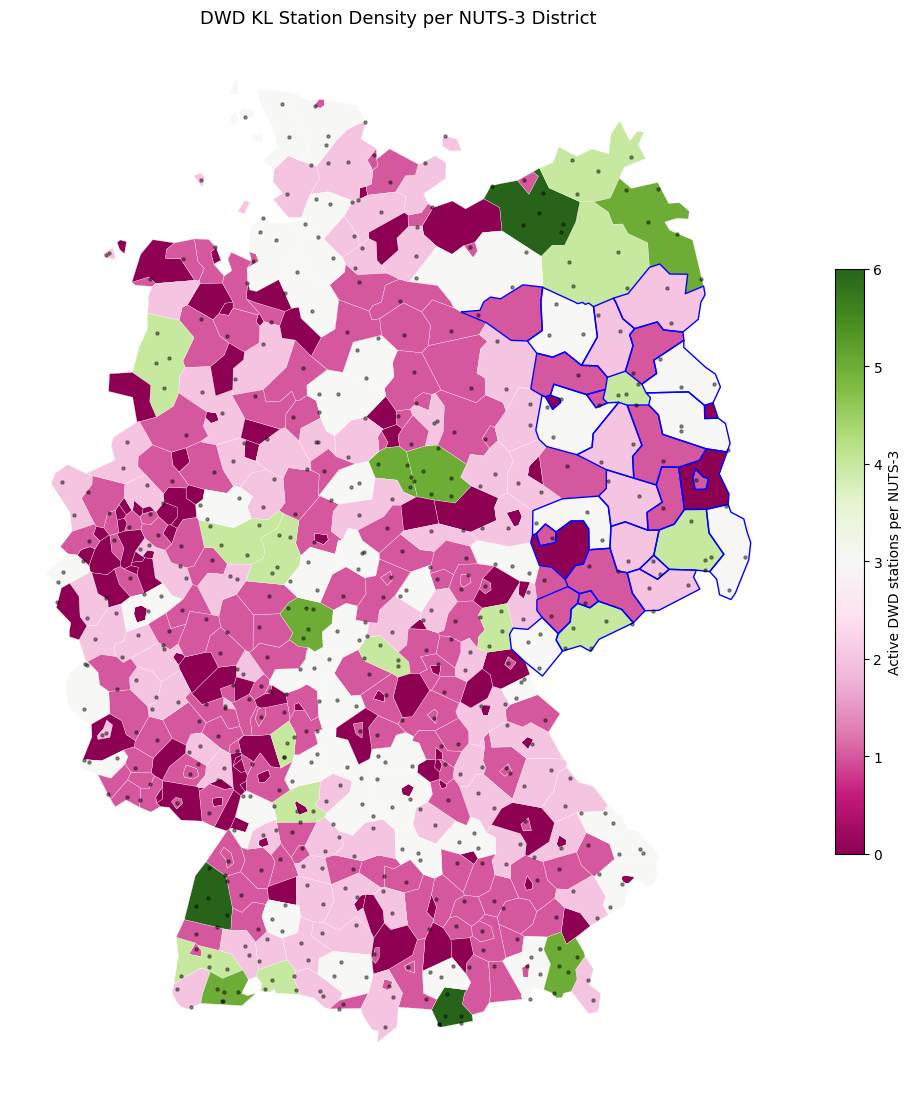

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(10, 12))

# Plot NUTS-3 overlay with gradient fill for coverage frequency
de_nuts3_gdf.plot(
    column="n_stations_active",
    ax=ax,
    legend=True,
    # cmap="YlOrRd",
    # cmap="inferno",
    # cmap="magma",
    # cmap="cividis",
    # cmap="BrBG",
    # cmap="coolwarm",
    # cmap="RdYlGn",
    # cmap="RdBu",
    cmap="PiYG",
    # cmap="PRGn",
    edgecolor="white",
    linewidth=0.2,
    missing_kwds={"color": "lightgray"},
    legend_kwds={"label": "Active DWD stations per NUTS-3", "shrink": 0.5},
)

# Overlay the DWD stations
ax.scatter(active_stations_df["lon"], active_stations_df["lat"], s=5, c="black", alpha=0.4, zorder=5, label="DWD stations")

# Highlight Lusatia
lusatia_gdf = de_nuts3_gdf[de_nuts3_df["nuts1_code"].isin(["DE4", "DED"])]
lusatia_gdf.boundary.plot(ax=ax, edgecolor="blue", linewidth=1.0, zorder=4)

ax.set_title("DWD KL Station Density per NUTS-3 District", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

/var/folders/8l/pdw1tpc15616zvq3yj3p1hsh0000gp/T/ipykernel_8869/894758889.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("PiYG")


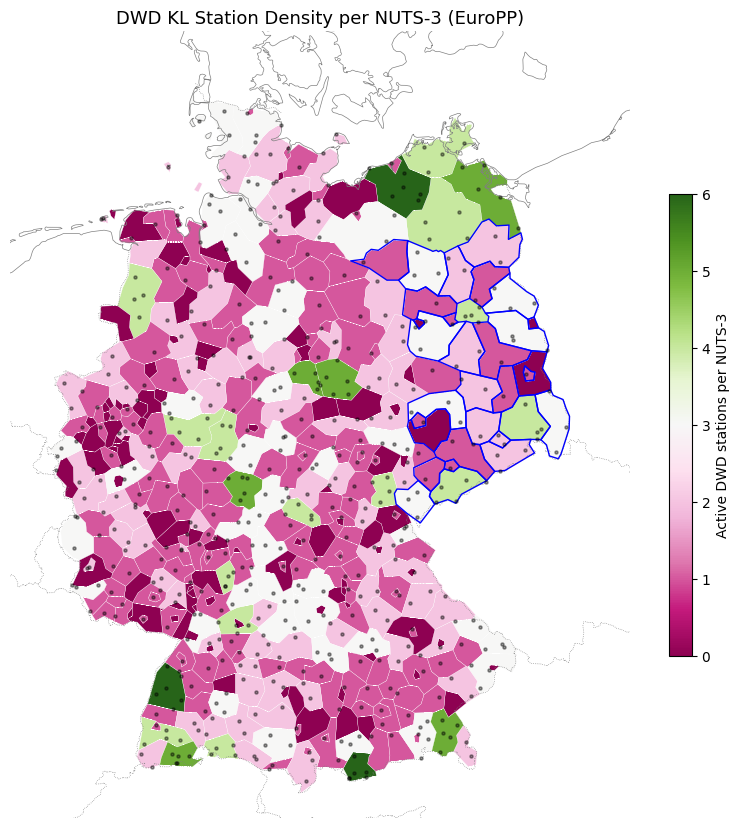

In [35]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.cm as cm
import matplotlib.colors as mcolors

proj = ccrs.EuroPP()  # LAEA Europe (≈ EPSG:3035)
fig = plt.figure(figsize=(10, 12))
ax = fig.add_subplot(1, 1, 1, projection=proj)

ax.set_extent([5.5, 15.5, 47.0, 55.5], crs=ccrs.PlateCarree())  # constrain extent to DE

cmap = cm.get_cmap("PiYG")
col = de_nuts3_gdf["n_stations_active"]
norm = mcolors.Normalize(vmin=col.min(), vmax=col.max())

# Chloropleth via Cartopy's add_geometries (otherwise ignored kwargs to mpl plot)
for _, row in de_nuts3_gdf.iterrows():
    val = row["n_stations_active"]
    fc = "lightgray" if pd.isna(val) else cmap(norm(val))
    ax.add_geometries([row.geometry], crs=ccrs.PlateCarree(), facecolor=fc, edgecolor="white", linewidth=0.2)

lusatia = de_nuts3_gdf[de_nuts3_gdf["nuts1_code"].isin(["DE4", "DED"])]
ax.add_geometries(lusatia.geometry, crs=ccrs.PlateCarree(), facecolor="none", edgecolor="blue", linewidth=1.0, zorder=4)

# Uses WGS-84 coords, hence needs the transform
ax.scatter(
    active_stations_df["lon"],
    active_stations_df["lat"],
    s=5,
    c="black",
    alpha=0.4,
    zorder=5,
    transform=ccrs.PlateCarree(),
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.5, edgecolor="gray")
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="gray", linestyle=":")

# ax.set_extent([5.5, 15.5, 47.0, 55.5], crs=ccrs.PlateCarree())  # constrain extent to DE

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []
fig.colorbar(sm, ax=ax, shrink=0.5, label="Active DWD stations per NUTS-3")

ax.set_title("DWD KL Station Density per NUTS-3 (EuroPP)", fontsize=13)
ax.set_axis_off()
plt.show()

In [36]:
import folium
from branca.colormap import LinearColormap

hex_stops = [mcolors.to_hex(cmap(i / 4)) for i in range(5)]

vmax = int(de_nuts3_gdf["n_stations_active"].max())
colormap = LinearColormap(
    # ["#ffffb2", "#fd8d3c", "#bd0026"],
    # ["#000000", "#fdff3c", "#00bb00"],
    hex_stops,
    vmin=0,
    vmax=vmax,
    caption="Active DWD stations per NUTS-3",
)

m = folium.Map(location=[51.2, 10.4], zoom_start=6, tiles="CartoDB positron")

folium.GeoJson(
    de_nuts3_gdf[["NUTS_ID", "NUTS_NAME", "nuts1_code", "n_stations_active", "geometry"]].to_json(),
    style_function=lambda f: {
        "fillColor": colormap(f["properties"]["n_stations_active"] or 0),
        "color": "white",
        "weight": 0.5,
        "fillOpacity": 0.7,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["NUTS_ID", "NUTS_NAME", "n_stations_active"],
        aliases=["NUTS-3", "Name", "Active stations"],
    ),
).add_to(m)

# Station dots
for _, r in active_stations_df.iterrows():
    folium.CircleMarker(
        [r.lat, r.lon],
        radius=1,
        color="black",
        fill=True,
        fill_opacity=0.5,
        tooltip=f"{r.station_id}",
    ).add_to(m)

# Lusatia contour overlay
folium.GeoJson(
    lusatia_gdf[["geometry"]].to_json(),
    style_function=lambda f: {
        "fillOpacity": 0,
        "color": "blue",
        "weight": 2,
    },
    interactive=False,
    name="Lusatia",
).add_to(m)

colormap.add_to(m)
m

## 5. Nearest-station fallback for zero-coverage districts

For districts with no station inside their boundary, find the nearest station using distance calculation.

For each district without active stations, find the nearest active station using centroid-to-station distance (approximate, planar on EPSG:3035):

In [37]:
zero_ids = density_all_df[density_all_df["n_stations_active"] == 0]["nuts3_id"].tolist()
zero_ids[:3]

['DE117', 'DE122', 'DE125']

In [38]:
# Build placeholders for SQL IN clause
id_list = ", ".join(f"'{x}'" for x in zero_ids)

fallback = con.sql(f"""
    with district_centroids as (
        select nuts_id
             , nuts_name
             , st_x(st_centroid(geometry)) as cx
             , st_y(st_centroid(geometry)) as cy
        from nuts3
        where nuts_id in ({id_list})
    ),
    active_stations as (
        select station_id, station_name, lon, lat, nuts3_id as home_nuts3
        from dwd_stations_nuts3
        where date_to >= '2024-01-01'
    ),
    distances as (
        select d.nuts_id   as gap_nuts3
             , d.nuts_name as gap_name
             , a.station_id
             , a.station_name
             , a.home_nuts3
             -- approximate distance in degrees (good enough for ranking)
             , sqrt(power(d.cx - a.lon, 2) + power(d.cy - a.lat, 2)) as dist_deg
        from       district_centroids d
        cross join active_stations    a
    ),
    ranked as (
        select *, row_number() over (partition by gap_nuts3 order by dist_deg) as rnk
        from distances
    )
    select gap_nuts3, gap_name, station_id, station_name, home_nuts3
         , round(dist_deg * 111, 1) as approx_km  -- rough deg->km
    from ranked
    where rnk = 1
    order by approx_km desc
""").df()
fallback

,gap_nuts3,gap_name,station_id,station_name,home_nuts3,approx_km
0,DE94B,Grafschaft Bentheim,03254,Meppen,DE949,42.3
1,DEB1A,Rhein-Lahn-Kreis,01580,Geisenheim,DEB3J,32.7
2,DE27C,Unterallgäu,03244,Memmingen,DE274,27.9
3,DE267,Haßberge,01107,Ebrach,DE245,26.5
4,DE93B,Verden,04275,Rotenburg (Wümme),DE937,26.0
...,...,...,...,...,...,...
93,DE117,"Heilbronn, Stadtkreis",15547,Heilbronn/Neckar,DE118,5.9
94,DE223,"Straubing, Kreisfreie Stadt",04911,Straubing,DE22B,5.8
95,DEA55,"Herne, Kreisfreie Stadt",00555,Bochum,DEA51,4.7
96,DE26C,"Würzburg, Landkreis",05705,Würzburg,DE263,4.2


**Note on limitation**: Without elevation data in the distance calculation, we're treating this as a flat-plane approximation. 

This is acceptable for the predominantly lowland regions in our focus area (Brandenburg, Saxony), but may understate actual climate differences in mountainous districts where lapse-rate effects are significant.

So we've calculated the nearest-station fallbacks for 98 no-coverage districts:

In [39]:
len(fallback)

98

with max imputed distance of 42.3km:

In [40]:
print(fallback["approx_km"].max())

42.3


and the median imputed distance of 15.3km:

In [41]:
print(fallback["approx_km"].median())

15.25


## 6. Decision and Registry Entry

Assess whether station-based weather at NUTS-3 is viable, and register the data source.

### Decision on DWD KL Station -> NUTS-3 Mapping

Brief summary:


- **Source**: DWD CDC KL daily (historical)
- **URL**:    https://opendata.dwd.de/climate_environment/CDC/
- **Auth**:   None (open data)

- **Gap fallback**: Nearest station (median 15 km, max 42 km)
- **Variables**:    TMK (mean temp °C), RSK (precipitation mm)
- **Temporal**:     Daily, many stations from 1950s+

Consider the coverage as a quality gate, including historical stations (for long-record analysis):

In [42]:
coverage_pct = (density_all_df["n_stations_active"] > 0).sum() / 401 * 100
coverage_hist = (density_all_df["n_stations_all"] > 0).sum() / 401 * 100
coverage_pct, coverage_hist

(np.float64(75.56109725685786), np.float64(91.02244389027432))

In [43]:
print(f"""
Total stations:   {len(stations_df)}
Active stations:  {(stations_df["date_to"] >= "2024-01-01").sum()}
NUTS-3 coverage:  {coverage_pct:.0f}% active | {coverage_hist:.0f}% any historical
""")


Total stations:   1382
Active stations:  576
NUTS-3 coverage:  76% active | 91% any historical



- So we have 76% direct NUTS-3 coverage (active) and 91% with historical station data.
- With nearest-station fallback (15km median, 42km max), effective coverage is 100%.

We defined our threshold at 80%. With 76%/91% it is still defensible, and nearest-neighbor gap filling brings it to interpolated 100%. But it also suggests we need to evaluate gridded sources (HYRAS, REGNIE).

In [44]:
decision = "ingest"
reason = f"{coverage_pct:.0f}% direct NUTS-3 coverage (active), {coverage_hist:.0f}% with historical; remaining via nearest-station fallback (median 15 km)"

### Register in data_source_registry


In [45]:
con.sql("""
    create table if not exists data_source_registry (
        source_name    varchar primary key,
        url            varchar,
        spatial_level  varchar,
        temporal_range varchar,
        variables      varchar,
        auth_required  boolean,
        decision       varchar,
        reason         varchar,
        coverage_pct   float,
        evaluated_at   timestamp default current_timestamp)
""")

Describe the data source as briefly summarized just above.

In [46]:
con.execute(
    """
    insert or replace into data_source_registry values (
        'dwd_kl_stations',
        'https://opendata.dwd.de/climate_environment/CDC/observations_germany/climate/daily/kl/historical/',
        'point -> NUTS-3 via ST_Contains',
        '1950s-present (daily)',
        'TMK (mean temp °C), RSK (precipitation mm)',
        false,
        $1, $2, $3,
        current_timestamp)
    """,
    [decision, reason, float(coverage_pct)],
)

In [47]:
con.sql("select source_name, decision, coverage_pct from data_source_registry").show()

┌─────────────────┬──────────┬──────────────┐
│   source_name   │ decision │ coverage_pct │
│     varchar     │ varchar  │    float     │
├─────────────────┼──────────┼──────────────┤
│ dwd_kl_stations │ ingest   │      75.5611 │
└─────────────────┴──────────┴──────────────┘



Release the DuckDB connection to finish this notebook script.

In [48]:
con.close()